# 19.1) Base Plano de Saúde 

## Regressão com vetores de suporte => Base Plano Saúde. 

In [59]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [60]:
base_plano_saude2 = pd.read_csv('plano_saude2.csv')
base_plano_saude2

,idade,custo
0,18,470
1,23,520
2,28,630
3,33,830
4,38,1150
5,43,1530
6,48,2040
7,53,3080
8,58,5100
9,63,10100


In [61]:
X_plano_saude2 = base_plano_saude2.iloc[:, 0:1].values #o x recebe os dados da idade
y_plano_saude2 = base_plano_saude2.iloc[:, 1].values # o y que desejamos prever é o do custo

In [62]:
X_plano_saude2 # atributo preditor, que é a idade.

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [63]:
y_plano_saude2 # respectivos preços. 

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

Algoritmo do SVR é caracterizado pela aplicação de kernel, kernel linear, kernel polinomial, e o kernel RBF (melhor desempenho)

O kernel RBF (Radial Basis Function), também conhecido como kernel gaussiano, é uma função kernel popular usada em algoritmos de aprendizado de máquina, especialmente em máquinas de vetores de suporte (SVM) e kernels k-vizinhos mais próximos. Ele calcula a similaridade entre dois pontos de dados com base em sua distância euclidiana em um espaço de alta dimensão, projetando os dados de forma não linear. 

https://en.wikipedia.org/wiki/Radial_basis_function_kernel

In [64]:
# problemas de classificação e regressão => kernel linear

## kernel linear

In [65]:
# Kernel linear
from sklearn.svm import SVR
regressor_svr_saude_linear = SVR(kernel = 'linear')
regressor_svr_saude_linear.fit(X_plano_saude2, y_plano_saude2)  # treinamento 

SVR(kernel='linear')

In [66]:
regressor_svr_saude_linear.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [67]:
# maior o C, mais os algoitmos vão se adaptar aos dados. 

In [68]:
regressor_svr_saude_linear.predict(X_plano_saude2) # preditor

array([ 216.14,  520.1 ,  824.06, 1128.02, 1431.98, 1735.94, 2039.9 ,
       2343.86, 2647.82, 2951.78])

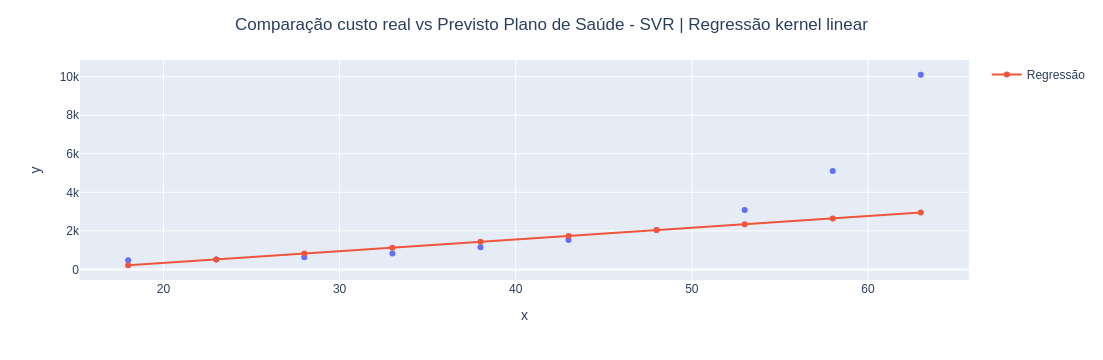

In [69]:
# distribuição com o svr
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = regressor_svr_saude_linear.predict(X_plano_saude2), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão kernel linear',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_5.html")  # valor real o azul, previsto o vermelho regressão

In [70]:
# os dados que estão na nossa base de dados não se adaptam às previsões lineares. 

## Kernel polinomial

In [71]:
# Kernel polinomial
regressor_svr_saude_poly = SVR(kernel='poly', degree=4) # versão elevado ao quadrado, ao cubo e a quarta.
regressor_svr_saude_poly.fit(X_plano_saude2, y_plano_saude2) # treinamento

SVR(degree=4, kernel='poly')

In [72]:
regressor_svr_saude_poly.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 4,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'poly',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

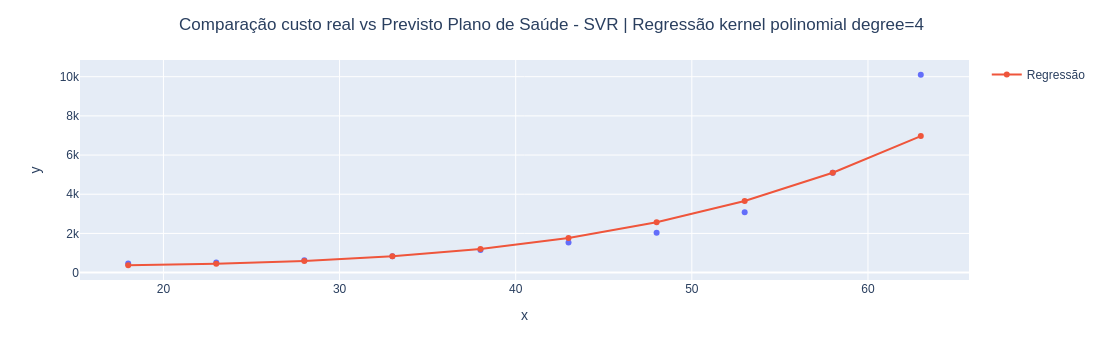

In [73]:
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = regressor_svr_saude_poly.predict(X_plano_saude2), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão kernel polinomial degree=4',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_51.html")  # valor real o azul, previsto o vermelho regressão

{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'poly', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


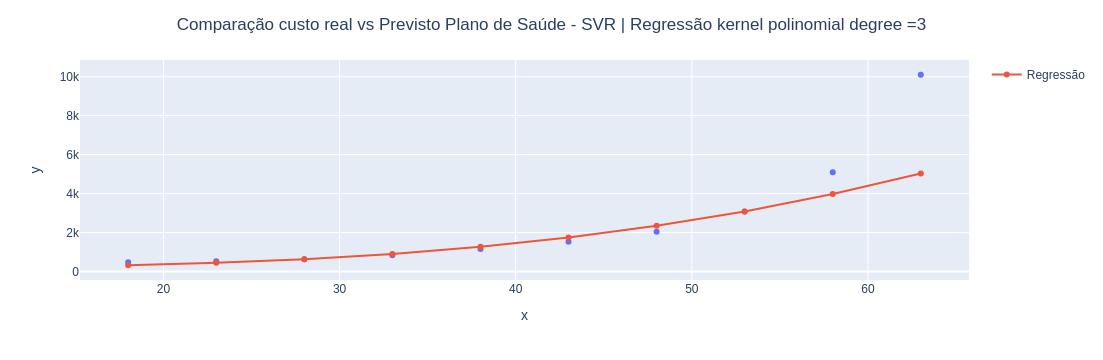

In [74]:
# Kernel polinomial
regressor_svr_saude_poly = SVR(kernel='poly', degree=3) # versão elevado ao quadrado, ao cubo.
regressor_svr_saude_poly.fit(X_plano_saude2, y_plano_saude2) # treinamento

print(regressor_svr_saude_poly.get_params())

grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = regressor_svr_saude_poly.predict(X_plano_saude2), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão kernel polinomial degree =3',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_52.html")  # valor real o azul, previsto o vermelho regressão

In [75]:
# resultado melhor com o grau, degree 4.

## Kernel rbf

In [76]:
# Kernel rbf
regressor_svr_saude_rbf = SVR(kernel='rbf')
regressor_svr_saude_rbf.fit(X_plano_saude2, y_plano_saude2) # treinamento

SVR()

In [77]:
regressor_svr_saude_rbf.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

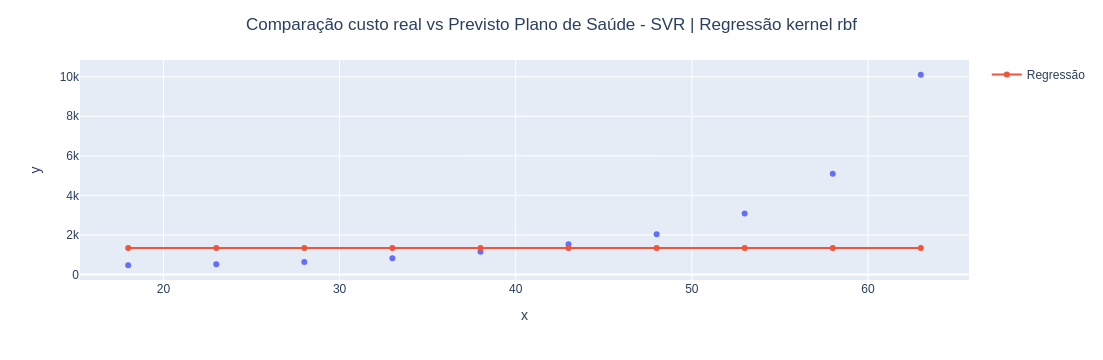

In [78]:
# ficou estranho a previsão
grafico = px.scatter(x = X_plano_saude2.ravel(), y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2.ravel(), y = regressor_svr_saude_rbf.predict(X_plano_saude2), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão kernel rbf',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_53.html")  # valor real o azul, previsto o vermelho regressão

no kernel rbf tem que adaptar, os dados de x e y apresentam escalas diferentes, ou seja, não estão normalizados. 


os outros algoritmos não são necessários aplicar a normalização ou a padronização, pois internamente tanto a regressão linear quanto a árvore de decisão, quanto Random Forest aplicam a normalização internamente. 

Já no SVR temos que normalizar manualmente esses dados. 

## Cálculo que utiliza a média e o desvio padrão para deixar os dados na mesma escala. 

In [79]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [80]:
y_plano_saude2

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [81]:
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # método para padronizar ou normalizar os dados com a média e o desvio padrão. 
X_plano_saude2_scaled = scaler_x.fit_transform(X_plano_saude2)
scaler_y = StandardScaler() # método para padronizar ou normalizar os dados com a média e o desvio padrão. 
y_plano_saude2_scaled = scaler_y.fit_transform(y_plano_saude2.reshape(-1,1)) # estava em formato de vetor e temos que transformar em matriz.

In [82]:
X_plano_saude2_scaled

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [83]:
y_plano_saude2_scaled

array([[-0.72401136],
       [-0.7065653 ],
       [-0.66818397],
       [-0.59839975],
       [-0.48674498],
       [-0.35415495],
       [-0.17620517],
       [ 0.18667281],
       [ 0.8914935 ],
       [ 2.63609918]])

In [84]:
# padronizamos todos os dados e ficaram com dados menores.

In [85]:
# Kernel rbf
regressor_svr_saude_rbf = SVR(kernel='rbf')
regressor_svr_saude_rbf.fit(X_plano_saude2_scaled, y_plano_saude2_scaled.ravel()) # treinamento 
# o y tem que ser com 1 dimensão (colocar ravel) e não com duas dimensões como na base de dados. 

SVR()

In [86]:
regressor_svr_saude_rbf.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

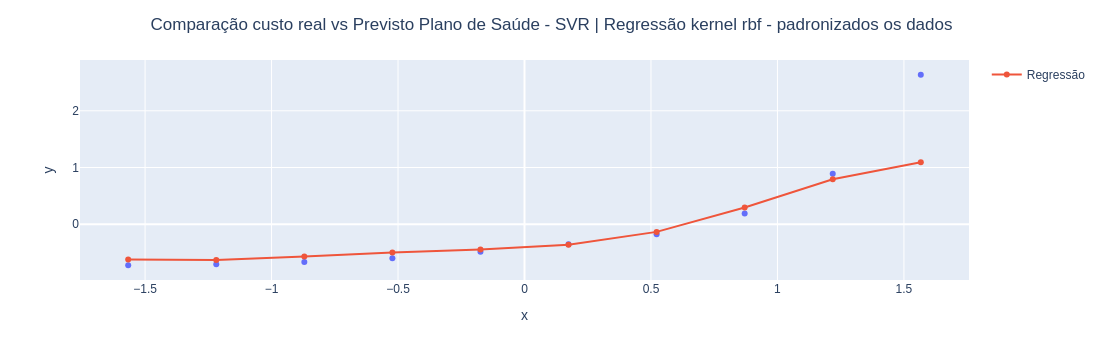

In [87]:
grafico = px.scatter(x = X_plano_saude2_scaled.ravel(), y = y_plano_saude2_scaled.ravel())
grafico.add_scatter(x = X_plano_saude2_scaled.ravel(), y = regressor_svr_saude_rbf.predict(X_plano_saude2_scaled), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Plano de Saúde - SVR | Regressão kernel rbf - padronizados os dados',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_54.html")  # valor real o azul, previsto o vermelho regressão


Como fazer a previsão:



In [88]:

regressor_svr_saude_rbf.predict([[40]]) # os valores estão sendo retornados os escalonados. Ou seja, os padronizados. 

array([0.01359678])

In [89]:
novo = [[40]] # 40 anos previsão para os preços do plano de saúde. 

In [90]:
# precisamos escalonar os valores da idade.
novo = scaler_x.transform(novo)
novo # idade de 40 anos escalonados

array([[-0.03481553]])

In [91]:
# retorno escalonado
regressor_svr_saude_rbf.predict(novo)

array([-0.42259356])

In [92]:
#preço do plano de saúde, inverso transporte => com o valor real. 
scaler_y.inverse_transform(regressor_svr_saude_rbf.predict(novo).reshape(-1, 1))

array([[1333.85650748]])

In [94]:
preco_forecast = scaler_y.inverse_transform(regressor_svr_saude_rbf.predict(novo).reshape(-1, 1))

In [98]:
print(f'{40} anos com o Preço de R$ {preco_forecast[0][0]:2f} ')

40 anos com o Preço de R$ 1333.856507 
